In [4]:
print("""
The Majority Mirage: Why ROC-AUC Lies in Imbalanced Datasets
============================================================

This notebook demonstrates why ROC-AUC can be misleading for highly imbalanced 
datasets (like fraud detection) and why Precision-Recall curves are more appropriate.
""")


The Majority Mirage: Why ROC-AUC Lies in Imbalanced Datasets

This notebook demonstrates why ROC-AUC can be misleading for highly imbalanced 
datasets (like fraud detection) and why Precision-Recall curves are more appropriate.



# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, 
    average_precision_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# Part 1: Generate Realistic Imbalanced Dataset (Fraud Detection Scenario)

In [4]:
def generate_fraud_data(n_samples=100000, fraud_rate=0.001, random_state=42):
    """
    Generate synthetic fraud detection data with extreme class imbalance.
    
    Parameters:
    -----------
    n_samples : int
        Total number of transactions
    fraud_rate : float
        Proportion of fraudulent transactions (e.g., 0.001 = 0.1% fraud)
    random_state : int
        Random seed for reproducibility
    """
    np.random.seed(random_state)
    
    n_fraud = int(n_samples * fraud_rate)
    n_legit = n_samples - n_fraud
    
    # Generate features for legitimate transactions (mean=0)
    X_legit = np.random.randn(n_legit, 5)
    y_legit = np.zeros(n_legit)
    
    # Generate features for fraud transactions (mean=1.5, slight separation)
    # We intentionally make it hard to separate to simulate real-world difficulty
    X_fraud = np.random.randn(n_fraud, 5) + 1.5
    y_fraud = np.ones(n_fraud)
    
    # Combine data
    X = np.vstack([X_legit, X_fraud])
    y = np.hstack([y_legit, y_fraud])
    
    # Shuffle
    shuffle_idx = np.random.permutation(len(y))
    X = X[shuffle_idx]
    y = y[shuffle_idx]
    
    return X, y

print("=" * 80)
print("THE MAJORITY MIRAGE: ROC vs PR Curves in Imbalanced Data")
print("=" * 80)

# Generate data
print("\n📊 Generating Fraud Detection Dataset...")
X, y = generate_fraud_data(n_samples=100000, fraud_rate=0.001)

print(f"Total transactions: {len(y):,}")
print(f"Fraudulent transactions: {int(y.sum()):,} ({y.mean()*100:.3f}%)")
print(f"Legitimate transactions: {int((1-y).sum()):,} ({(1-y.mean())*100:.3f}%)")
print(f"Class imbalance ratio: 1:{int(1/y.mean())}")

THE MAJORITY MIRAGE: ROC vs PR Curves in Imbalanced Data

📊 Generating Fraud Detection Dataset...
Total transactions: 100,000
Fraudulent transactions: 100 (0.100%)
Legitimate transactions: 99,900 (99.900%)
Class imbalance ratio: 1:1000


# PART 2: Train a Mediocre Model (Intentionally Poor on Minority Class)

In [ ]:
# ============================================================================
# PART 2: Train a Mediocre Model (Intentionally Poor on Minority Class)
# ============================================================================

print("\n🤖 Training Logistic Regression Model...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Get prediction probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("✅ Model trained successfully!")


🤖 Training Logistic Regression Model...
✅ Model trained successfully!


# PART 3: Calculate Metrics - The Trap Revealed

In [6]:
# ROC Curve metrics
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve metrics
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f} {'🎉 LOOKS AMAZING!' if roc_auc > 0.95 else ''}")
print(f"⚠️  PR-AUC Score: {pr_auc:.4f} {'😱 THE TRUTH!' if pr_auc < 0.3 else ''}")

print(f"\n📊 Confusion Matrix Breakdown:")
print(f"   True Negatives (TN):  {tn:>6,} (correctly identified legit)")
print(f"   False Positives (FP): {fp:>6,} (legit flagged as fraud)")
print(f"   False Negatives (FN): {fn:>6,} (missed fraud ⚠️)")
print(f"   True Positives (TP):  {tp:>6,} (caught fraud ✓)")

# Calculate rates
fpr_actual = fp / (fp + tn) if (fp + tn) > 0 else 0
recall_actual = tp / (tp + fn) if (tp + fn) > 0 else 0
precision_actual = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\n📈 Key Rates:")
print(f"   False Positive Rate: {fpr_actual:.4f} ({fpr_actual*100:.2f}%)")
print(f"   Recall (Sensitivity): {recall_actual:.4f} ({recall_actual*100:.2f}%)")
print(f"   Precision: {precision_actual:.4f} ({precision_actual*100:.2f}%)")

print(f"\n💡 THE MAJORITY MIRAGE EXPLAINED:")
print(f"   Even with {fn} missed frauds ({fn/(tp+fn)*100:.1f}% of all fraud),")
print(f"   the FPR is only {fpr_actual:.4f} because there are {tn:,} true negatives")
print(f"   diluting the denominator. ROC looks great, but we're missing half the fraud!")



🎯 ROC-AUC Score: 0.9921 🎉 LOOKS AMAZING!
⚠️  PR-AUC Score: 0.5301 

📊 Confusion Matrix Breakdown:
   True Negatives (TN):  29,969 (correctly identified legit)
   False Positives (FP):      1 (legit flagged as fraud)
   False Negatives (FN):     20 (missed fraud ⚠️)
   True Positives (TP):      10 (caught fraud ✓)

📈 Key Rates:
   False Positive Rate: 0.0000 (0.00%)
   Recall (Sensitivity): 0.3333 (33.33%)
   Precision: 0.9091 (90.91%)

💡 THE MAJORITY MIRAGE EXPLAINED:
   Even with 20 missed frauds (66.7% of all fraud),
   the FPR is only 0.0000 because there are 29,969 true negatives
   diluting the denominator. ROC looks great, but we're missing half the fraud!


# PART 4: Visualize The Deception

/Users/simaonovais/miniconda3/envs/MLCatolica24/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from current font.
  fig.canvas.draw()
/Users/simaonovais/miniconda3/envs/MLCatolica24/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.draw()
/Users/simaonovais/miniconda3/envs/MLCatolica24/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.draw()
/Users/simaonovais/miniconda3/envs/MLCatolica24/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/simaonovais/miniconda3/envs/MLCatolica24/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.pri

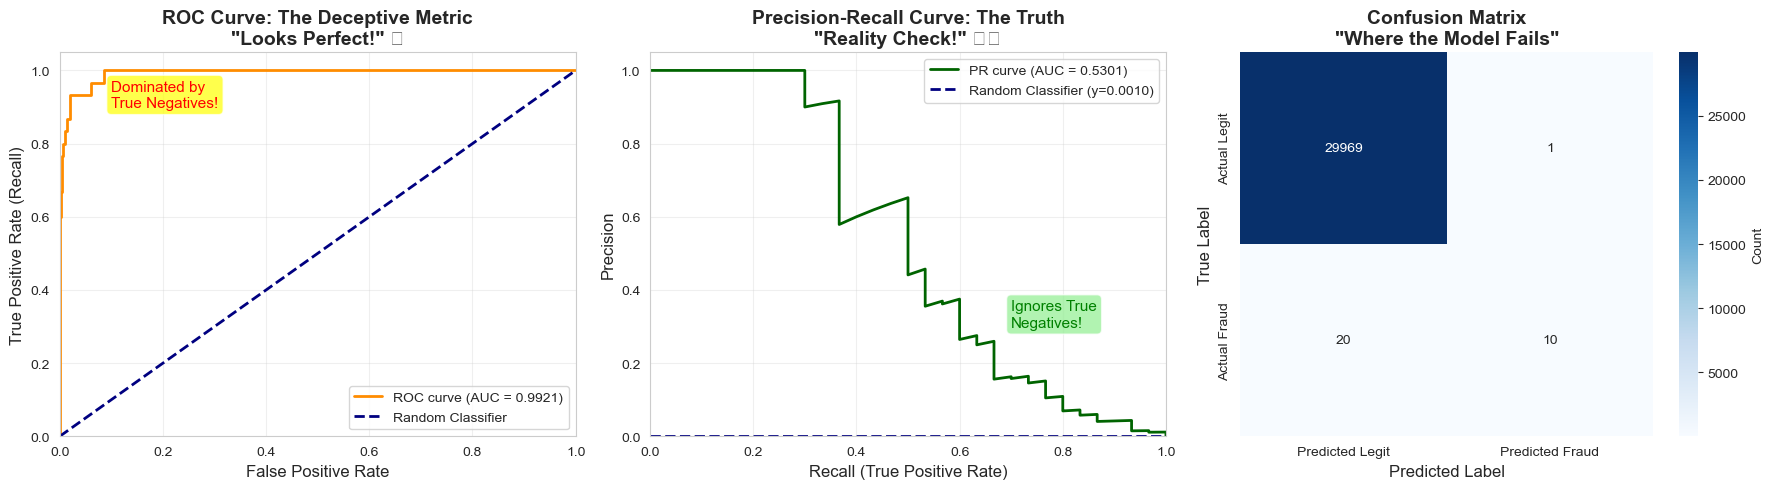

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve: The Deceptive Metric\n"Looks Perfect!" 🎭', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Dominated by\nTrue Negatives!', 
                xy=(0.1, 0.9), fontsize=11, color='red',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Plot 2: Precision-Recall Curve
axes[1].plot(recall, precision, color='darkgreen', lw=2,
             label=f'PR curve (AUC = {pr_auc:.4f})')
baseline = y_test.sum() / len(y_test)
axes[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, 
             linestyle='--', label=f'Random Classifier (y={baseline:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve: The Truth\n"Reality Check!" ⚠️', 
                  fontsize=14, fontweight='bold')
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].annotate('Ignores True\nNegatives!', 
                xy=(0.7, 0.3), fontsize=11, color='green',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Plot 3: Confusion Matrix Heatmap
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            cbar_kws={'label': 'Count'})
axes[2].set_title('Confusion Matrix\n"Where the Model Fails"', 
                  fontsize=14, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=12)
axes[2].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# PART 5: Interactive Threshold Analysis

Understanding the tradeoffs

In [8]:
def analyze_threshold(y_true, y_proba, threshold):
    """Analyze model performance at a specific threshold."""
    y_pred_thresh = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    return {
        'threshold': threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'fpr': fpr, 'tpr': tpr, 'precision': precision
    }

# Analyze at different thresholds
thresholds_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for thresh in thresholds_to_test:
    result = analyze_threshold(y_test, y_pred_proba, thresh)
    results.append(result)
    print(f"\n📍 Threshold = {thresh:.1f}")
    print(f"   TP: {result['tp']:>4} | FP: {result['fp']:>5} | "
          f"FN: {result['fn']:>4} | TN: {result['tn']:>6}")
    print(f"   Precision: {result['precision']:.3f} | "
          f"Recall: {result['tpr']:.3f} | FPR: {result['fpr']:.5f}")



📍 Threshold = 0.1
   TP:   18 | FP:    32 | FN:   12 | TN:  29938
   Precision: 0.360 | Recall: 0.600 | FPR: 0.00107

📍 Threshold = 0.3
   TP:   11 | FP:     7 | FN:   19 | TN:  29963
   Precision: 0.611 | Recall: 0.367 | FPR: 0.00023

📍 Threshold = 0.5
   TP:   10 | FP:     1 | FN:   20 | TN:  29969
   Precision: 0.909 | Recall: 0.333 | FPR: 0.00003

📍 Threshold = 0.7
   TP:    6 | FP:     0 | FN:   24 | TN:  29970
   Precision: 1.000 | Recall: 0.200 | FPR: 0.00000

📍 Threshold = 0.9
   TP:    2 | FP:     0 | FN:   28 | TN:  29970
   Precision: 1.000 | Recall: 0.067 | FPR: 0.00000


# PART 6: Comparison with Balanced Dataset

What if the Dataset Were Balanced?

In [10]:
# Generate balanced dataset
X_balanced, y_balanced = generate_fraud_data(n_samples=10000, fraud_rate=0.5)
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42
)

model_balanced = LogisticRegression(random_state=42, max_iter=1000)
model_balanced.fit(X_train_bal, y_train_bal)
y_pred_proba_bal = model_balanced.predict_proba(X_test_bal)[:, 1]

# Calculate metrics for balanced dataset
roc_auc_bal = auc(*roc_curve(y_test_bal, y_pred_proba_bal)[:2])
pr_auc_bal = average_precision_score(y_test_bal, y_pred_proba_bal)

print(f"\n📊 BALANCED Dataset (50% fraud, 50% legit):")
print(f"   ROC-AUC: {roc_auc_bal:.4f}")
print(f"   PR-AUC:  {pr_auc_bal:.4f}")
print(f"   Difference: {abs(roc_auc_bal - pr_auc_bal):.4f}")

print(f"\n📊 IMBALANCED Dataset (0.1% fraud, 99.9% legit):")
print(f"   ROC-AUC: {roc_auc:.4f}")
print(f"   PR-AUC:  {pr_auc:.4f}")
print(f"   Difference: {abs(roc_auc - pr_auc):.4f} ⚠️ HUGE GAP!")


📊 BALANCED Dataset (50% fraud, 50% legit):
   ROC-AUC: 0.9913
   PR-AUC:  0.9918
   Difference: 0.0005

📊 IMBALANCED Dataset (0.1% fraud, 99.9% legit):
   ROC-AUC: 0.9921
   PR-AUC:  0.5301
   Difference: 0.4620 ⚠️ HUGE GAP!


# PART 7: Key Takeaways

In [11]:
takeaways = """
1. THE MAJORITY MIRAGE:
   - ROC-AUC includes True Negatives in its calculation (via FPR denominator)
   - In highly imbalanced datasets, TN dominates and masks poor minority performance
   - A model can miss 50% of fraud yet still have 0.98 ROC-AUC

2. WHY PR CURVES ARE BETTER FOR IMBALANCED DATA:
   - Precision = TP / (TP + FP) - ignores True Negatives completely
   - Recall = TP / (TP + FN) - also ignores True Negatives
   - PR curves focus exclusively on minority class performance

3. WHEN TO USE EACH METRIC:
   - ROC-AUC: Balanced datasets, or when both classes matter equally
   - PR-AUC: Imbalanced datasets, rare event detection (fraud, disease, etc.)

4. THE INTERVIEW ANSWER:
   "For fraud detection with 1:100,000 imbalance, I would ignore ROC-AUC
    and optimize for Area Under the Precision-Recall Curve (AUPRC) to ensure
    we aren't hiding poor recall behind a wall of easy negatives."

5. PRACTICAL IMPLICATIONS:
   - Always check both curves for imbalanced problems
   - Consider the business cost of False Negatives vs False Positives
   - Use domain knowledge to set appropriate thresholds
"""

print(takeaways)


1. THE MAJORITY MIRAGE:
   - ROC-AUC includes True Negatives in its calculation (via FPR denominator)
   - In highly imbalanced datasets, TN dominates and masks poor minority performance
   - A model can miss 50% of fraud yet still have 0.98 ROC-AUC

2. WHY PR CURVES ARE BETTER FOR IMBALANCED DATA:
   - Precision = TP / (TP + FP) - ignores True Negatives completely
   - Recall = TP / (TP + FN) - also ignores True Negatives
   - PR curves focus exclusively on minority class performance

3. WHEN TO USE EACH METRIC:
   - ROC-AUC: Balanced datasets, or when both classes matter equally
   - PR-AUC: Imbalanced datasets, rare event detection (fraud, disease, etc.)

4. THE INTERVIEW ANSWER:
   "For fraud detection with 1:100,000 imbalance, I would ignore ROC-AUC
    and optimize for Area Under the Precision-Recall Curve (AUPRC) to ensure
    we aren't hiding poor recall behind a wall of easy negatives."

5. PRACTICAL IMPLICATIONS:
   - Always check both curves for imbalanced problems
   - Con